# CSE36301 Assignment3
### Dataset: Breast Cancer Wisconsin (sklearn)
---


## 0. Setup & Dataset Load

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Hyperparameters
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Print dataset information
print('X shape:', X.shape)
print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Classes:', data.target_names)

X shape: (569, 30)
Train: (455, 30) Test: (114, 30)
Classes: ['malignant' 'benign']


In [2]:
# Print dataset description
print(data['DESCR'])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

## 1. Ensemble Learning

In [3]:
import numpy as np

def gini_impurity(y):
    # TODO: Calculate Gini impurity for labels y.
    classes, counts = np.unique(y, return_counts=True)
    probabilities = counts / len(y)
    gini = 1 - np.sum(probabilities ** 2)
    return gini

def split_dataset(X, y, feature_index, threshold):
    # TODO: Split dataset into left/right subsets based on feature threshold.
    left_mask = X[:, feature_index] <= threshold
    right_mask = X[:, feature_index] > threshold
    return X[left_mask], y[left_mask], X[right_mask], y[right_mask]

class Node:
    def __init__(self, feature_index=None, threshold=None, left=None, right=None, value=None):
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value  # class label for leaf node

# TODO: Implement Decision Tree from Scratch
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None

    def fit(self, X, y):
        self.root = self._build_tree(X, y, depth=0)

    def _build_tree(self, X, y, depth):
        num_samples, num_features = X.shape
        num_labels = len(np.unique(y))

        # Stopping conditions
        if (self.max_depth is not None and depth >= self.max_depth) or \
           num_labels == 1 or \
           num_samples < self.min_samples_split:
            leaf_value = self._majority_vote(y)
            return Node(value=leaf_value)

        # Find best split
        best_feature, best_threshold, best_gain = None, None, -1
        parent_impurity = gini_impurity(y)

        for feature_index in range(num_features):
            thresholds = np.unique(X[:, feature_index])
            for threshold in thresholds:
                X_left, y_left, X_right, y_right = split_dataset(X, y, feature_index, threshold)
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                # TODO: Compute weighted Gini
                n_left, n_right = len(y_left), len(y_right)
                weighted_gini = (n_left / num_samples) * gini_impurity(y_left) + \
                                (n_right / num_samples) * gini_impurity(y_right)

                # TODO: Update best split
                # 정보 이득 = 부모 불순도 - 자식 가중 불순도
                gain = parent_impurity - weighted_gini
                if gain > best_gain:  # 더 좋은 분할이면 업데이트
                    best_gain = gain
                    best_feature = feature_index
                    best_threshold = threshold

        # If no gain, make leaf
        if best_gain == 0:
            leaf_value = self._majority_vote(y)
            return Node(value=leaf_value)

        # Split recursively
        X_left, y_left, X_right, y_right = split_dataset(X, y, best_feature, best_threshold)
        left_child = self._build_tree(X_left, y_left, depth + 1)
        right_child = self._build_tree(X_right, y_right, depth + 1)
        return Node(feature_index=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def _majority_vote(self, y):
        # TODO: Return the most common class label in y
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def predict(self, X):
        return np.array([self._predict_one(x, self.root) for x in X])

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature_index] <= node.threshold:
            return self._predict_one(x, node.left)
        else:
            return self._predict_one(x, node.right)

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

MAX_DEPTH = 10
N_ESTIMATORS = 100

# Define Decision Tree
tree = DecisionTree(max_depth=MAX_DEPTH)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))
print(f"Decision Tree Accuracy: {acc_tree:.3f}")

# Define Random Forest
rf = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy: {acc_rf:.3f}")

Decision Tree Accuracy: 0.930
Random Forest Accuracy: 0.956


In [5]:
from collections import Counter

# Implement Bagging
def bagging_classifier(X_train, y_train, X_test, n_estimators=10, max_depth=None):
    n_samples = X_train.shape[0]
    preds_all = []
    for i in range(n_estimators):
        # TODO: Bootstrap sampling
        # 1. Randomly sample 'n_samples' indices with replacement from the training set.
        indices = np.random.choice(n_samples, size=n_samples, replace=True)
        X_boot = X_train[indices]
        y_boot = y_train[indices]
        # 2. Train a Decision Tree on the sampled data.
        tree = DecisionTree(max_depth=max_depth)
        tree.fit(X_boot, y_boot)
        # 3. Predict on the test set and store the predictions.
        pred = tree.predict(X_test)
        preds_all.append(pred)

    preds_all = np.array(preds_all)
    final = []
    for col in preds_all.T:
        final.append(Counter(col).most_common(1)[0][0])
    return np.array(final)

y_pred_bag = bagging_classifier(X_train, y_train, X_test, n_estimators=N_ESTIMATORS)
acc_bag = accuracy_score(y_test, y_pred_bag)
print(f"Bagging Accuracy: {acc_bag:.3f}")

Bagging Accuracy: 0.939


In [6]:
from sklearn.tree import DecisionTreeClassifier

# Implement AdaBoost
def adaboost_binary(X_train, y_train, X_test, n_estimators=20):
    y_mod = np.where(y_train == 0, -1, 1)
    n = len(y_train)
    w = np.ones(n) / n
    models, alphas = [], []

    for m in range(n_estimators):
        stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE)
        stump.fit(X_train, y_mod, sample_weight=w)
        pred = stump.predict(X_train)

        # TODO: Compute weighted error
        misclassified = (pred != y_mod)
        err = np.sum(w * misclassified) / np.sum(w)
        
        if err <= 1e-10:
            alpha = 1.0
        else:
            # TODO: Compute model weight (alpha)
            # alpha = 0.5 * ln((1-err)/err)
            alpha = 0.5 * np.log((1 - err) / err)

        # TODO: Update sample weights
        # 틀린 샘플의 가중치는 증가, 맞춘 샘플의 가중치는 감소
        w = w * np.exp(-alpha * y_mod * pred)
        w = w / np.sum(w)  # 정규화

        models.append(stump)
        alphas.append(alpha)

    # TODO: Make final predictions on the test set
    final_score = np.zeros(len(X_test))
    for alpha, model in zip(alphas, models):
        pred_test = model.predict(X_test)
        final_score += alpha * pred_test

    y_final = np.sign(final_score)
    y_final = np.where(y_final == -1, 0, 1)
    acc = accuracy_score(y_test, y_final)
    return acc

acc_ada = adaboost_binary(X_train, y_train, X_test, n_estimators=N_ESTIMATORS)
print(f"AdaBoost Accuracy: {acc_ada:.3f}")

AdaBoost Accuracy: 0.956


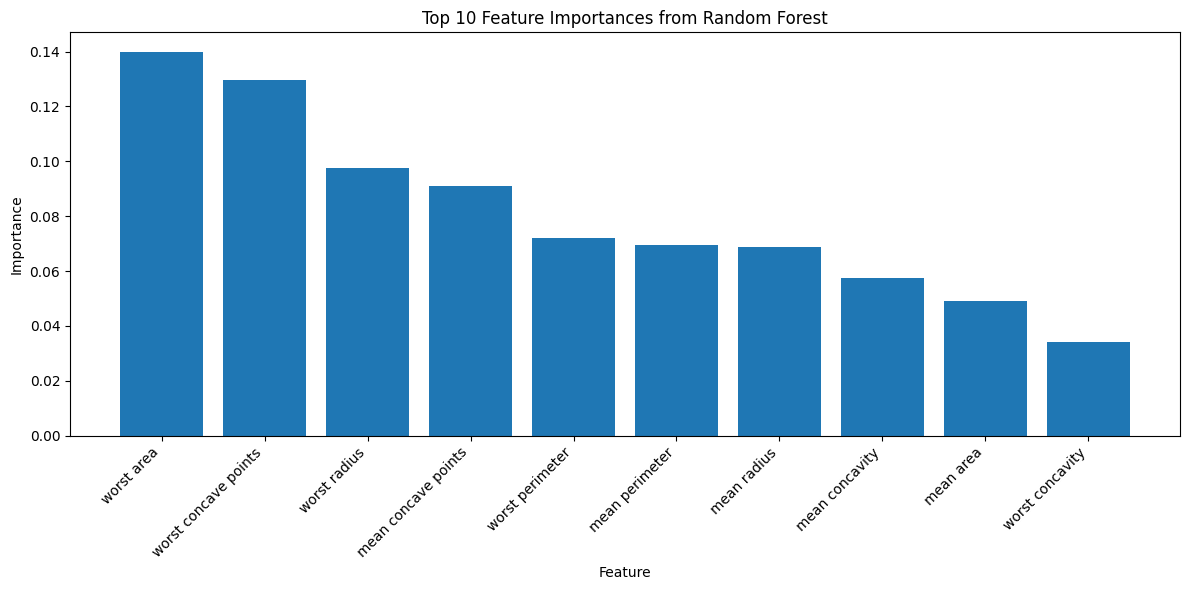

Top 10 Most Important Features:
1. worst area: 0.1400
2. worst concave points: 0.1295
3. worst radius: 0.0977
4. mean concave points: 0.0909
5. worst perimeter: 0.0722
6. mean perimeter: 0.0696
7. mean radius: 0.0687
8. mean concavity: 0.0576
9. mean area: 0.0492
10. worst concavity: 0.0343


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Visualize Feature importance
# 1. Extract feature importances from the Random Forest model. (rf.feature_importances_)
# 2. Create a bar plot to display the importance of each feature.
importances = rf.feature_importances_

feature_names = data.feature_names

# 중요도 순으로 정렬
indices = np.argsort(importances)[::-1]

# 상위 10개 특징 시각화
plt.figure(figsize=(12, 6))
plt.bar(range(10), importances[indices][:10])
plt.xticks(range(10), [feature_names[i] for i in indices[:10]], rotation=45, ha='right')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Top 10 Feature Importances from Random Forest')
plt.tight_layout()
plt.show()

# 상위 10개 특징 출력
print("Top 10 Most Important Features:")
for i in range(10):
    print(f"{i+1}. {feature_names[indices[i]]}: {importances[indices[i]]:.4f}")

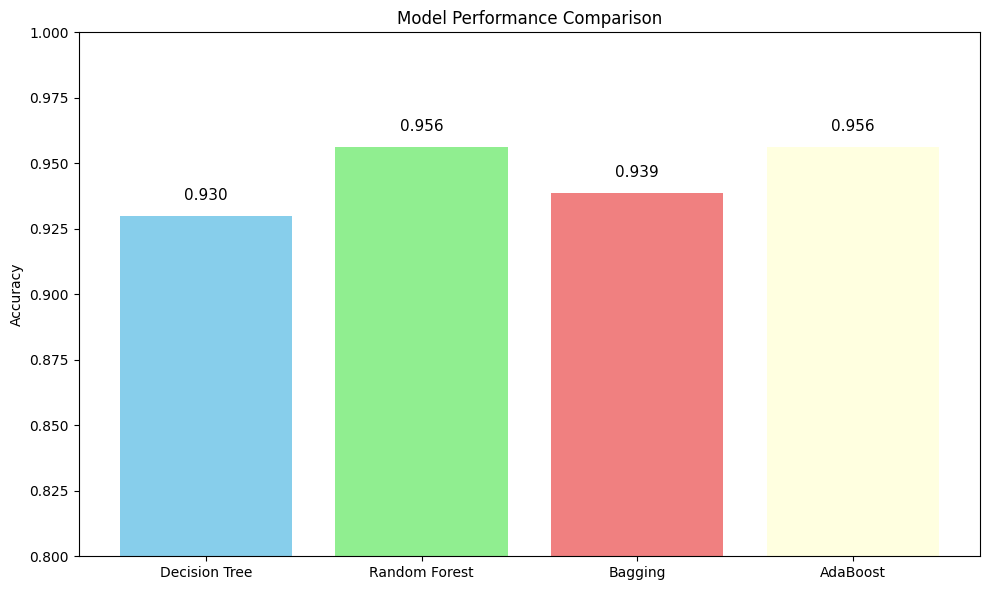


=== Model Performance Summary ===
Decision Tree       : 0.930
Random Forest       : 0.956
Bagging             : 0.939
AdaBoost            : 0.956


In [8]:
# TODO: Compare 4 models
# Create a bar plot comparing the accuracy of Decision Tree, Random Forest, Bagging, and AdaBoost.
models = ['Decision Tree', 'Random Forest', 'Bagging', 'AdaBoost']
accuracies = [acc_tree, acc_rf, acc_bag, acc_ada]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['skyblue', 'lightgreen', 'lightcoral', 'lightyellow'])
plt.ylabel('Accuracy')
plt.title('Model Performance Comparison')
plt.ylim(0.8, 1.0)

# 각 막대 위에 정확도 값 표시
for i, (model, acc) in enumerate(zip(models, accuracies)):
    plt.text(i, acc + 0.005, f'{acc:.3f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# 수치로도 출력
print("\n=== Model Performance Summary ===")
for model, acc in zip(models, accuracies):
    print(f"{model:20s}: {acc:.3f}")

In [9]:
# TODO (Analysis)
# Change the TEST_SIZE hyperparameter and observe which ensemble method remains the most stable when the dataset is relatively small. Experiment by varying n_estimators.
# Select the 10 most important features from the Random Forest, visualize them, and analyze how the accuracy changes when training with only these features.

Q1: Change the TEST_SIZE hyperparameter and observe which ensemble method remains the most stable when the dataset is relatively small. Experiment by varying n_estimators.

--- Testing with n_estimators = 50 ---
TEST_SIZE=0.1: DT=0.930, RF=0.947, Bag=0.947, Ada=0.965
TEST_SIZE=0.1: DT=0.930, RF=0.947, Bag=0.947, Ada=0.965
TEST_SIZE=0.2: DT=0.930, RF=0.956, Bag=0.930, Ada=0.956
TEST_SIZE=0.2: DT=0.930, RF=0.956, Bag=0.930, Ada=0.956
TEST_SIZE=0.3: DT=0.918, RF=0.924, Bag=0.936, Ada=0.959
TEST_SIZE=0.3: DT=0.918, RF=0.924, Bag=0.936, Ada=0.959
TEST_SIZE=0.4: DT=0.934, RF=0.947, Bag=0.917, Ada=0.961
TEST_SIZE=0.4: DT=0.934, RF=0.947, Bag=0.917, Ada=0.961
TEST_SIZE=0.5: DT=0.912, RF=0.947, Bag=0.926, Ada=0.965

--- Testing with n_estimators = 100 ---
TEST_SIZE=0.5: DT=0.912, RF=0.947, Bag=0.926, Ada=0.965

--- Testing with n_estimators = 100 ---
TEST_SIZE=0.1: DT=0.930, RF=0.965, Bag=0.947, Ada=0.965
TEST_SIZE=0.1: DT=0.930, RF=0.965, Bag=0.947, Ada=0.965
TEST_SIZE=0.2: DT=0.930, RF=0.956,

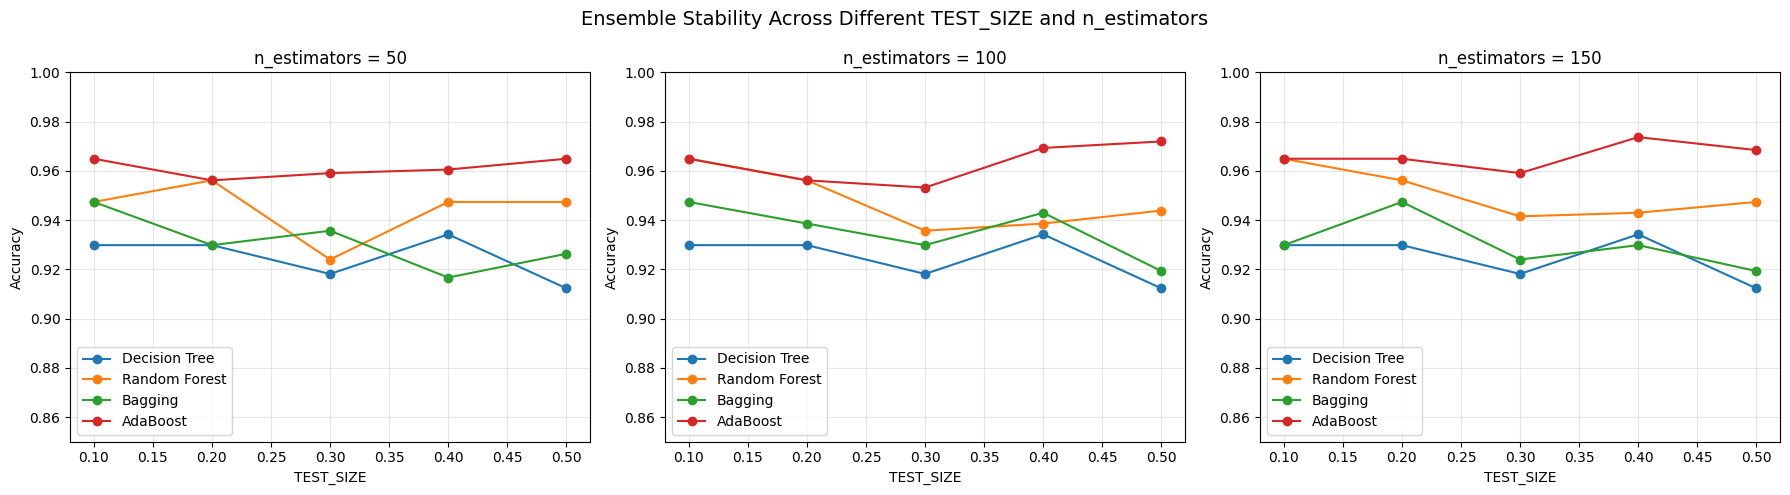

In [10]:
print("Q1: Change the TEST_SIZE hyperparameter and observe which ensemble method remains the most stable when the dataset is relatively small. Experiment by varying n_estimators.")

test_sizes = [0.1, 0.2, 0.3, 0.4, 0.5]
n_estimators_list = [50, 100, 150]

# 각 모델의 결과를 저장할 딕셔너리
results = {
    'Decision Tree': {n_est: [] for n_est in n_estimators_list},
    'Random Forest': {n_est: [] for n_est in n_estimators_list},
    'Bagging': {n_est: [] for n_est in n_estimators_list},
    'AdaBoost': {n_est: [] for n_est in n_estimators_list}
}

# 각 TEST_SIZE와 n_estimators 조합에 대해 실험
for n_est in n_estimators_list:
    print(f"\n--- Testing with n_estimators = {n_est} ---", flush=True)
    
    for test_size in test_sizes:
        # 데이터 재분할
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=test_size, random_state=RANDOM_STATE, stratify=y
        )
        
        # Decision Tree
        tree_temp = DecisionTree(max_depth=MAX_DEPTH)
        tree_temp.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, tree_temp.predict(X_te))
        results['Decision Tree'][n_est].append(acc)
        
        # Random Forest
        rf_temp = RandomForestClassifier(n_estimators=n_est, random_state=RANDOM_STATE)
        rf_temp.fit(X_tr, y_tr)
        acc = accuracy_score(y_te, rf_temp.predict(X_te))
        results['Random Forest'][n_est].append(acc)
        
        # Bagging
        y_pred = bagging_classifier(X_tr, y_tr, X_te, n_estimators=n_est, max_depth=MAX_DEPTH)
        acc = accuracy_score(y_te, y_pred)
        results['Bagging'][n_est].append(acc)
        
        # AdaBoost - 전역 변수 y_test를 임시로 변경
        original_y_test = y_test
        y_test = y_te
        acc = adaboost_binary(X_tr, y_tr, X_te, n_estimators=n_est)
        y_test = original_y_test
        results['AdaBoost'][n_est].append(acc)
        
        print(f"TEST_SIZE={test_size:.1f}: DT={results['Decision Tree'][n_est][-1]:.3f}, RF={results['Random Forest'][n_est][-1]:.3f}, Bag={results['Bagging'][n_est][-1]:.3f}, Ada={results['AdaBoost'][n_est][-1]:.3f}", flush=True)


# 시각화: 각 n_estimators별로 그래프 생성
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Ensemble Stability Across Different TEST_SIZE and n_estimators', fontsize=14)

for idx, n_est in enumerate(n_estimators_list):
    ax = axes[idx]
    for model_name in results.keys():
        ax.plot(test_sizes, results[model_name][n_est], marker='o', label=model_name)
    
    ax.set_xlabel('TEST_SIZE')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'n_estimators = {n_est}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.85, 1.0)

plt.tight_layout()
plt.show()

Q2: Select the 10 most important features from the Random Forest, visualize them, and analyze how the accuracy changes when training with only these features.

Top 10 features: [np.str_('worst area'), np.str_('worst concave points'), np.str_('worst radius'), np.str_('mean concave points'), np.str_('worst perimeter'), np.str_('mean perimeter'), np.str_('mean radius'), np.str_('mean concavity'), np.str_('mean area'), np.str_('worst concavity')]

--- Training Random Forest with Top 10 Features ---
Random Forest Accuracy (All 30 features): 0.9561
Random Forest Accuracy (Top 10 features): 0.9561
Accuracy difference: 0.0000


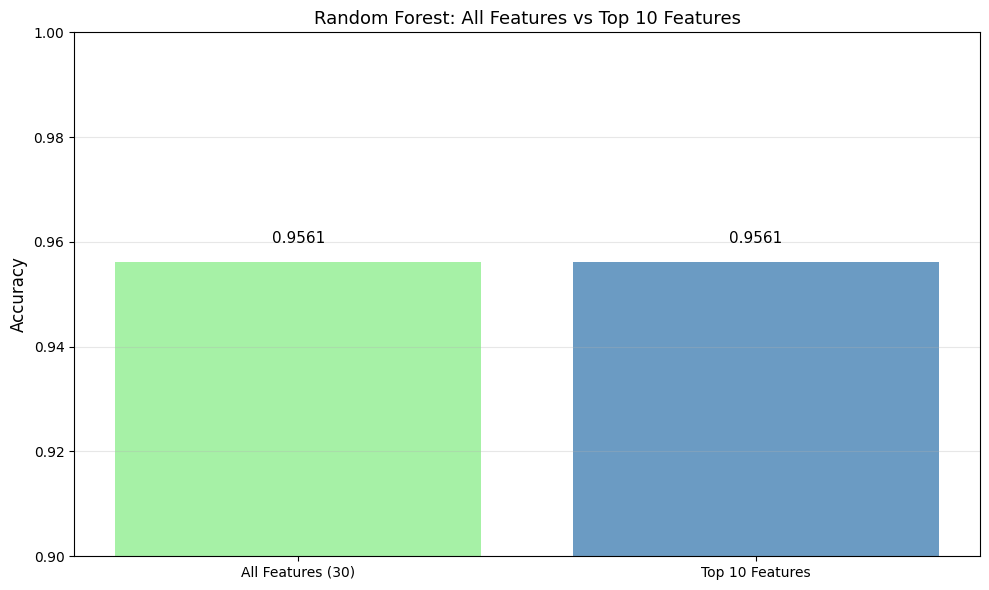

In [11]:
print("Q2: Select the 10 most important features from the Random Forest, visualize them, and analyze how the accuracy changes when training with only these features.")

# 상위 10개 특징 인덱스 추출 (이미 위에서 계산됨)
top_10_indices = indices[:10]
print(f"\nTop 10 features: {[data.feature_names[i] for i in top_10_indices]}")

# 원본 데이터셋으로 복원 (TEST_SIZE=0.2)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

# 상위 10개 특징만 선택
X_train_top10 = X_train[:, top_10_indices]
X_test_top10 = X_test[:, top_10_indices]

# Random Forest 학습 및 평가
print("\n--- Training Random Forest with Top 10 Features ---")

rf_top10 = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
rf_top10.fit(X_train_top10, y_train)
acc_rf_top10 = accuracy_score(y_test, rf_top10.predict(X_test_top10))

print(f"Random Forest Accuracy (All 30 features): {acc_rf:.4f}")
print(f"Random Forest Accuracy (Top 10 features): {acc_rf_top10:.4f}")
print(f"Accuracy difference: {acc_rf - acc_rf_top10:.4f}")

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

models = ['All Features (30)', 'Top 10 Features']
accuracies = [acc_rf, acc_rf_top10]

bars = ax.bar(models, accuracies, color=['lightgreen', 'steelblue'], alpha=0.8)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Random Forest: All Features vs Top 10 Features', fontsize=13)
ax.set_ylim([0.90, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# 각 막대 위에 정확도 값 표시
for i, acc in enumerate(accuracies):
    ax.text(i, acc + 0.003, f'{acc:.4f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()



## 2. Dimension Reduction

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: Implement PCA from Scratch (NumPy)
class PCA:
    def __init__(self, n_components=2):
        self.n_components = n_components
        self.mean = None
        self.components = None
        self.explained_variance_ratio_ = None

    # TODO: Implement fit, transform, methods
    def fit(self, X):
        # 1. Get Center the data
        self.mean = np.mean(X, axis=0)
        X_centered = X - self.mean

        # 2. Compute covariance matrix
        cov_matrix = np.cov(X_centered.T)

        # 3. Compute eigenvalues and eigenvectors
        eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

        # 4. Sort eigenvectors by eigenvalues in descending order
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx]
        eigenvectors = eigenvectors[:, idx]

        # 5. Store top components and explained variance ratio
        self.components = eigenvectors[:, :self.n_components]
        total_variance = np.sum(eigenvalues)
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / total_variance

    def transform(self, X):
        # 6. Project the data onto principal components
        X_centered = X - self.mean
        return np.dot(X_centered, self.components)

    def fit_transform(self, X):
        # TODO: fit and update explained_variance_ratio_ and return transformed data
        self.fit(X)
        return self.transform(X)

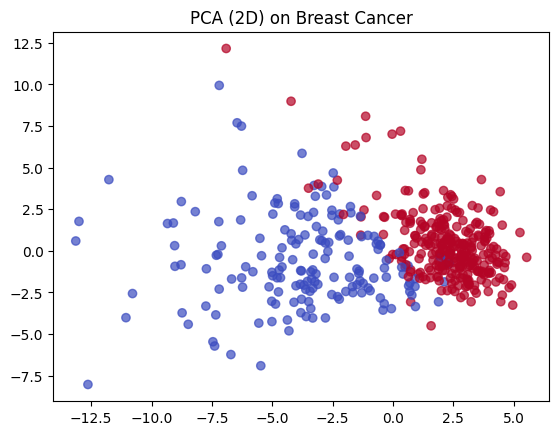


=== PCA Results ===
PC1 explains: 0.4441 (44.41%)
PC2 explains: 0.1894 (18.94%)
Total variance retained with 2 components: 0.6336 (63.36%)


In [13]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='coolwarm', alpha=0.7)
plt.title("PCA (2D) on Breast Cancer")
plt.show()

# TODO: What is the total retained variance with 2 components?
total_variance = np.sum(pca.explained_variance_ratio_)
print(f"\n=== PCA Results ===")
print(f"PC1 explains: {pca.explained_variance_ratio_[0]:.4f} ({pca.explained_variance_ratio_[0]*100:.2f}%)")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]:.4f} ({pca.explained_variance_ratio_[1]*100:.2f}%)")
print(f"Total variance retained with 2 components: {total_variance:.4f} ({total_variance*100:.2f}%)")

In [14]:
# TODO (Analysis)
# 1. How many principal components are required to retain more than 95% of the variance?
# 2. Apply Random Forest after PCA and compare the performance. Set n_estimators = 100.
# 3. Compare the performance between using the top n features selected by Random Forest feature importance and using n PCA components.

Q1: How many principal components are required to retain more than 95% of the variance?

Number of components needed for 95% variance: 10
Actual variance explained: 0.9527 (95.27%)

Top 10 components variance:
  PC1: 0.4441 (44.41%) | Cumulative: 0.4441 (44.41%)
  PC2: 0.1894 (18.94%) | Cumulative: 0.6336 (63.36%)
  PC3: 0.0954 (9.54%) | Cumulative: 0.7290 (72.90%)
  PC4: 0.0672 (6.72%) | Cumulative: 0.7963 (79.63%)
  PC5: 0.0552 (5.52%) | Cumulative: 0.8514 (85.14%)
  PC6: 0.0393 (3.93%) | Cumulative: 0.8908 (89.08%)
  PC7: 0.0218 (2.18%) | Cumulative: 0.9126 (91.26%)
  PC8: 0.0158 (1.58%) | Cumulative: 0.9284 (92.84%)
  PC9: 0.0128 (1.28%) | Cumulative: 0.9412 (94.12%)
  PC10: 0.0115 (1.15%) | Cumulative: 0.9527 (95.27%)


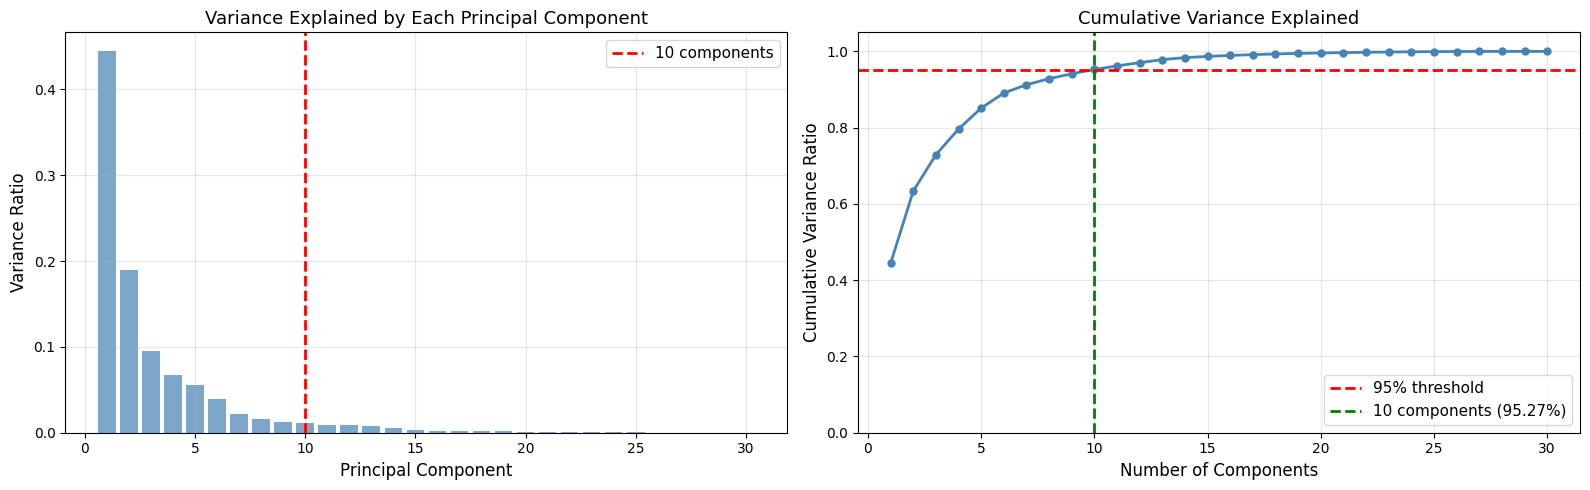

In [15]:
# Q1: How many principal components are required to retain more than 95% of the variance?
print("Q1: How many principal components are required to retain more than 95% of the variance?")


# 모든 주성분 계산
pca_full = PCA(n_components=X_train_scaled.shape[1])
pca_full.fit(X_train_scaled)

# 누적 분산 비율 계산
cumsum_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 95% 이상 유지하는 최소 주성분 개수 찾기
n_components_95 = np.argmax(cumsum_variance >= 0.95) + 1
variance_at_95 = cumsum_variance[n_components_95 - 1]

print(f"\nNumber of components needed for 95% variance: {n_components_95}")
print(f"Actual variance explained: {variance_at_95:.4f} ({variance_at_95*100:.2f}%)")

# 각 주성분별 분산 기여도 출력
print(f"\nTop {n_components_95} components variance:")
for i in range(n_components_95):
    print(f"  PC{i+1}: {pca_full.explained_variance_ratio_[i]:.4f} ({pca_full.explained_variance_ratio_[i]*100:.2f}%) | Cumulative: {cumsum_variance[i]:.4f} ({cumsum_variance[i]*100:.2f}%)")

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 개별 분산 비율
ax1.bar(range(1, len(pca_full.explained_variance_ratio_) + 1), 
        pca_full.explained_variance_ratio_, alpha=0.7, color='steelblue')
ax1.axvline(x=n_components_95, color='red', linestyle='--', linewidth=2, label=f'{n_components_95} components')
ax1.set_xlabel('Principal Component', fontsize=12)
ax1.set_ylabel('Variance Ratio', fontsize=12)
ax1.set_title('Variance Explained by Each Principal Component', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 누적 분산 비율
ax2.plot(range(1, len(cumsum_variance) + 1), cumsum_variance, marker='o', 
         linewidth=2, markersize=5, color='steelblue')
ax2.axhline(y=0.95, color='red', linestyle='--', linewidth=2, label='95% threshold')
ax2.axvline(x=n_components_95, color='green', linestyle='--', linewidth=2, 
            label=f'{n_components_95} components ({variance_at_95*100:.2f}%)')
ax2.set_xlabel('Number of Components', fontsize=12)
ax2.set_ylabel('Cumulative Variance Ratio', fontsize=12)
ax2.set_title('Cumulative Variance Explained', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

Q2: Apply Random Forest after PCA and compare the performance. Set n_estimators = 100.

Testing Random Forest with different number of PCA components:
   2 components (63.36% variance): Accuracy = 0.9386
   5 components (85.14% variance): Accuracy = 0.9298
  10 components (95.27% variance): Accuracy = 0.9386
   5 components (85.14% variance): Accuracy = 0.9298
  10 components (95.27% variance): Accuracy = 0.9386
  10 components (95.27% variance): Accuracy = 0.9386
  10 components (95.27% variance): Accuracy = 0.9386
  20 components (99.58% variance): Accuracy = 0.8947
  30 components (100.00% variance): Accuracy = 0.8947

Original (30 features, no PCA): Accuracy = 0.9561
  20 components (99.58% variance): Accuracy = 0.8947
  30 components (100.00% variance): Accuracy = 0.8947

Original (30 features, no PCA): Accuracy = 0.9561


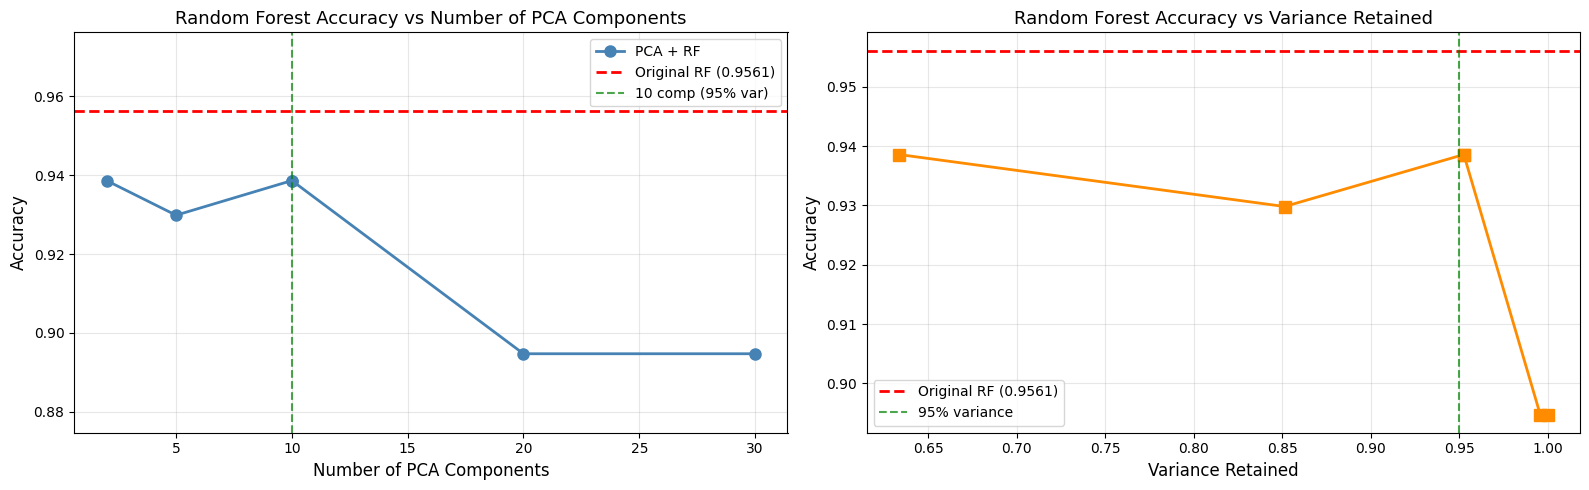

In [16]:
print("Q2: Apply Random Forest after PCA and compare the performance. Set n_estimators = 100.")


# 다양한 주성분 개수로 실험
component_counts = [2, 5, 10, n_components_95, 20, 30]
pca_rf_results = []

print("\nTesting Random Forest with different number of PCA components:")
for n_comp in component_counts:
    if n_comp > X_train_scaled.shape[1]:
        continue
        
    # PCA 적용
    pca_temp = PCA(n_components=n_comp)
    X_train_pca_temp = pca_temp.fit_transform(X_train_scaled)
    X_test_pca_temp = pca_temp.transform(X_test_scaled)
    
    # Random Forest 학습
    rf_pca = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_pca.fit(X_train_pca_temp, y_train)
    acc = accuracy_score(y_test, rf_pca.predict(X_test_pca_temp))
    
    variance_retained = np.sum(pca_temp.explained_variance_ratio_)
    pca_rf_results.append({
        'n_components': n_comp,
        'accuracy': acc,
        'variance': variance_retained
    })
    
    print(f"  {n_comp:2d} components ({variance_retained*100:5.2f}% variance): Accuracy = {acc:.4f}")

print(f"\nOriginal (30 features, no PCA): Accuracy = {acc_rf:.4f}")

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# 주성분 개수에 따른 정확도
n_comps = [r['n_components'] for r in pca_rf_results]
accs = [r['accuracy'] for r in pca_rf_results]

ax1.plot(n_comps, accs, marker='o', linewidth=2, markersize=8, color='steelblue', label='PCA + RF')
ax1.axhline(y=acc_rf, color='red', linestyle='--', linewidth=2, label=f'Original RF ({acc_rf:.4f})')
ax1.axvline(x=n_components_95, color='green', linestyle='--', linewidth=1.5, 
            alpha=0.7, label=f'{n_components_95} comp (95% var)')
ax1.set_xlabel('Number of PCA Components', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Random Forest Accuracy vs Number of PCA Components', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([min(accs) - 0.02, max(max(accs), acc_rf) + 0.02])

# 분산 유지율에 따른 정확도
variances = [r['variance'] for r in pca_rf_results]
ax2.plot(variances, accs, marker='s', linewidth=2, markersize=8, color='darkorange')
ax2.axhline(y=acc_rf, color='red', linestyle='--', linewidth=2, label=f'Original RF ({acc_rf:.4f})')
ax2.axvline(x=0.95, color='green', linestyle='--', linewidth=1.5, 
            alpha=0.7, label='95% variance')
ax2.set_xlabel('Variance Retained', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Random Forest Accuracy vs Variance Retained', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Q3: Compare the performance between using the top n features selected by Random Forest feature importance and using n PCA components.

Comparing Top-n Features (by importance) vs n PCA Components:

N     Top Features Acc     PCA Acc             
---------------------------------------------
2     0.9211             0.9386
5     0.9298             0.9298
10    0.9561             0.9386
5     0.9298             0.9298
10    0.9561             0.9386
15    0.9474             0.9298
20    0.9561             0.8947
15    0.9474             0.9298
20    0.9561             0.8947


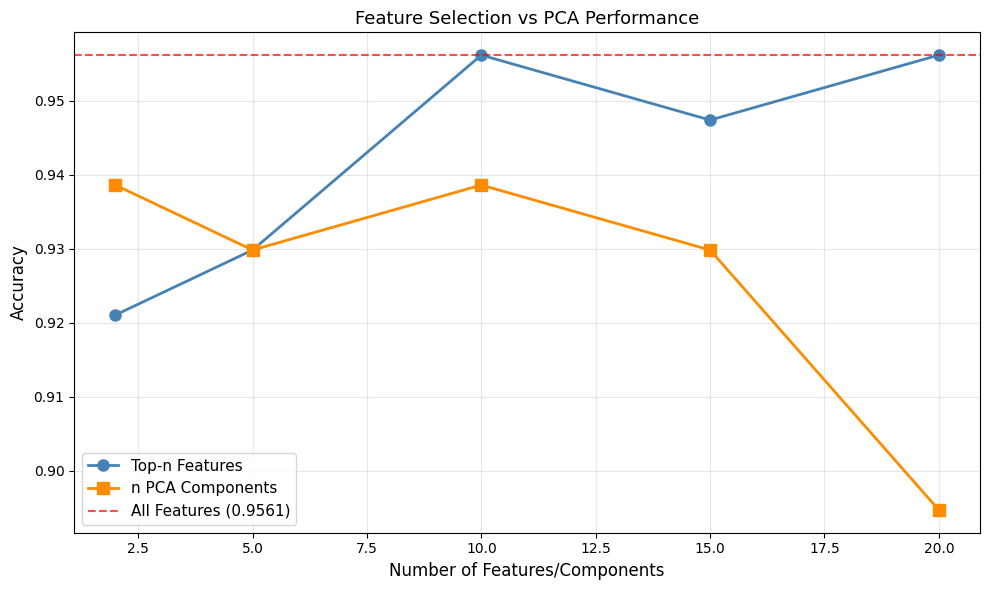

In [17]:
print("Q3: Compare the performance between using the top n features selected by Random Forest feature importance and using n PCA components.")

# 비교할 특징/주성분 개수
comparison_counts = [2, 5, 10, 15, 20]
feature_selection_results = []
pca_results_comparison = []

print("\nComparing Top-n Features (by importance) vs n PCA Components:\n")
print(f"{'N':<5} {'Top Features Acc':<20} {'PCA Acc':<20}")
print("-" * 45)

for n in comparison_counts:
    # Top n features (Feature Selection)
    top_n_indices = indices[:n]
    X_train_topn = X_train[:, top_n_indices]
    X_test_topn = X_test[:, top_n_indices]
    
    rf_feat = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_feat.fit(X_train_topn, y_train)
    acc_feat = accuracy_score(y_test, rf_feat.predict(X_test_topn))
    feature_selection_results.append(acc_feat)
    
    # n PCA components
    pca_comp = PCA(n_components=n)
    X_train_pca_comp = pca_comp.fit_transform(X_train_scaled)
    X_test_pca_comp = pca_comp.transform(X_test_scaled)
    
    rf_pca_comp = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
    rf_pca_comp.fit(X_train_pca_comp, y_train)
    acc_pca = accuracy_score(y_test, rf_pca_comp.predict(X_test_pca_comp))
    pca_results_comparison.append(acc_pca)
    
    print(f"{n:<5} {acc_feat:.4f}{'':12} {acc_pca:.4f}")

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

ax.plot(comparison_counts, feature_selection_results, marker='o', linewidth=2, 
        markersize=8, label='Top-n Features', color='steelblue')
ax.plot(comparison_counts, pca_results_comparison, marker='s', linewidth=2, 
        markersize=8, label='n PCA Components', color='darkorange')
ax.axhline(y=acc_rf, color='red', linestyle='--', linewidth=1.5, 
           alpha=0.7, label=f'All Features ({acc_rf:.4f})')
ax.set_xlabel('Number of Features/Components', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Feature Selection vs PCA Performance', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Neural Network

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# Convert data to PyTorch tensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Create DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

# Define MLP model
class MLP(nn.Module):
    def __init__(self, input_dim=30, hidden_dim=32, output_dim=2):
        super().__init__()
        # TODO: Define a simple MLP with one hidden layer using ReLU activation function (nn.ReLU())
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    def forward(self, x):
        return self.net(x)

Epoch 1/50 - loss: 0.6588 - acc: 0.877
Epoch 2/50 - loss: 0.5106 - acc: 0.939
Epoch 3/50 - loss: 0.4020 - acc: 0.947
Epoch 4/50 - loss: 0.3103 - acc: 0.939
Epoch 5/50 - loss: 0.2445 - acc: 0.939
Epoch 6/50 - loss: 0.2007 - acc: 0.939
Epoch 7/50 - loss: 0.1744 - acc: 0.947
Epoch 8/50 - loss: 0.1564 - acc: 0.956
Epoch 9/50 - loss: 0.1418 - acc: 0.956
Epoch 10/50 - loss: 0.1212 - acc: 0.956
Epoch 11/50 - loss: 0.1167 - acc: 0.956
Epoch 12/50 - loss: 0.1066 - acc: 0.956
Epoch 13/50 - loss: 0.0960 - acc: 0.956
Epoch 14/50 - loss: 0.0908 - acc: 0.956
Epoch 15/50 - loss: 0.0885 - acc: 0.956
Epoch 16/50 - loss: 0.0900 - acc: 0.974
Epoch 17/50 - loss: 0.0784 - acc: 0.974
Epoch 18/50 - loss: 0.0763 - acc: 0.974
Epoch 19/50 - loss: 0.0722 - acc: 0.965
Epoch 20/50 - loss: 0.0696 - acc: 0.965
Epoch 21/50 - loss: 0.0697 - acc: 0.965
Epoch 22/50 - loss: 0.0660 - acc: 0.965
Epoch 23/50 - loss: 0.0631 - acc: 0.965
Epoch 24/50 - loss: 0.0614 - acc: 0.974
Epoch 25/50 - loss: 0.0611 - acc: 0.974
Epoch 26/

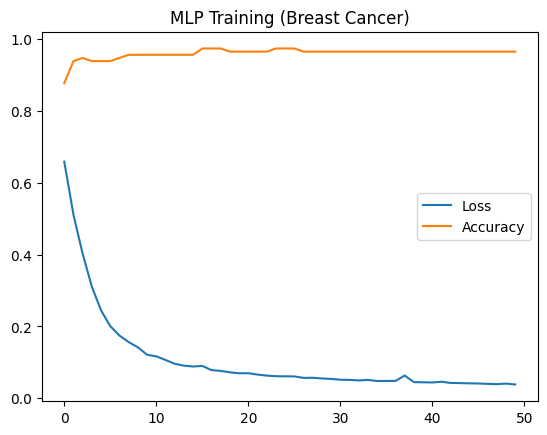

In [19]:
def train(epochs, model, train_loader, criterion, optimizer):
    loss_hist, acc_hist = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()

            # TODO: Forward pass, loss computation, backward pass
            # 1. Perform a forward pass through the model to get logits. xb is the input batch.
            # 2. Compute the loss using the criterion.
            # 3. Perform backpropagation by calling backward function.
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)

        model.eval()
        with torch.no_grad():
            logits_test = model(X_test_t)
            preds = logits_test.argmax(dim=1)
            acc = (preds == y_test_t).float().mean().item()

        loss_hist.append(avg_loss)
        acc_hist.append(acc)

        if (epoch+1) % 1 == 0:
            print(f"Epoch {epoch+1}/{epochs} - loss: {avg_loss:.4f} - acc: {acc:.3f}")

    return loss_hist, acc_hist

# Hyperparameters
LEARING_RATE = 0.001
EPOCHS = 50

# for classification
model = MLP(
    input_dim=X_train.shape[1],
    hidden_dim=16,
    output_dim=2
)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARING_RATE)
loss_hist, acc_hist = train(EPOCHS, model, train_loader, criterion, optimizer)

plt.plot(loss_hist, label='Loss')
plt.plot(acc_hist, label='Accuracy')
plt.legend()
plt.title("MLP Training (Breast Cancer)")
plt.show()

In [20]:
# TODO (Analysis)
# Change hidden_dim to 16, 32, and 64, and find which configuration achieves the best performance.
# Change the learning rate to 1e-4, 1e-3, and 1e-1, and compare training stability.
# Discuss which model—among Random Forest, Bagging, AdaBoost, and MLP—is the most suitable for this dataset.

Q1: Change hidden_dim to 16, 32, and 64, and find which configuration achieves the best performance.

--- Training MLP with hidden_dim = 16 ---
Epoch 10/50 - loss: 0.1173 - acc: 0.9737
Epoch 20/50 - loss: 0.0657 - acc: 0.9561
Epoch 30/50 - loss: 0.0506 - acc: 0.9649
Epoch 10/50 - loss: 0.1173 - acc: 0.9737
Epoch 20/50 - loss: 0.0657 - acc: 0.9561
Epoch 30/50 - loss: 0.0506 - acc: 0.9649
Epoch 40/50 - loss: 0.0441 - acc: 0.9649
Epoch 40/50 - loss: 0.0441 - acc: 0.9649
Epoch 50/50 - loss: 0.0373 - acc: 0.9561
Final Accuracy: 0.9561
Best Accuracy: 0.9737

--- Training MLP with hidden_dim = 32 ---
Epoch 10/50 - loss: 0.0956 - acc: 0.9649
Epoch 20/50 - loss: 0.0563 - acc: 0.9649
Epoch 50/50 - loss: 0.0373 - acc: 0.9561
Final Accuracy: 0.9561
Best Accuracy: 0.9737

--- Training MLP with hidden_dim = 32 ---
Epoch 10/50 - loss: 0.0956 - acc: 0.9649
Epoch 20/50 - loss: 0.0563 - acc: 0.9649
Epoch 30/50 - loss: 0.0459 - acc: 0.9649
Epoch 30/50 - loss: 0.0459 - acc: 0.9649
Epoch 40/50 - loss: 0.03

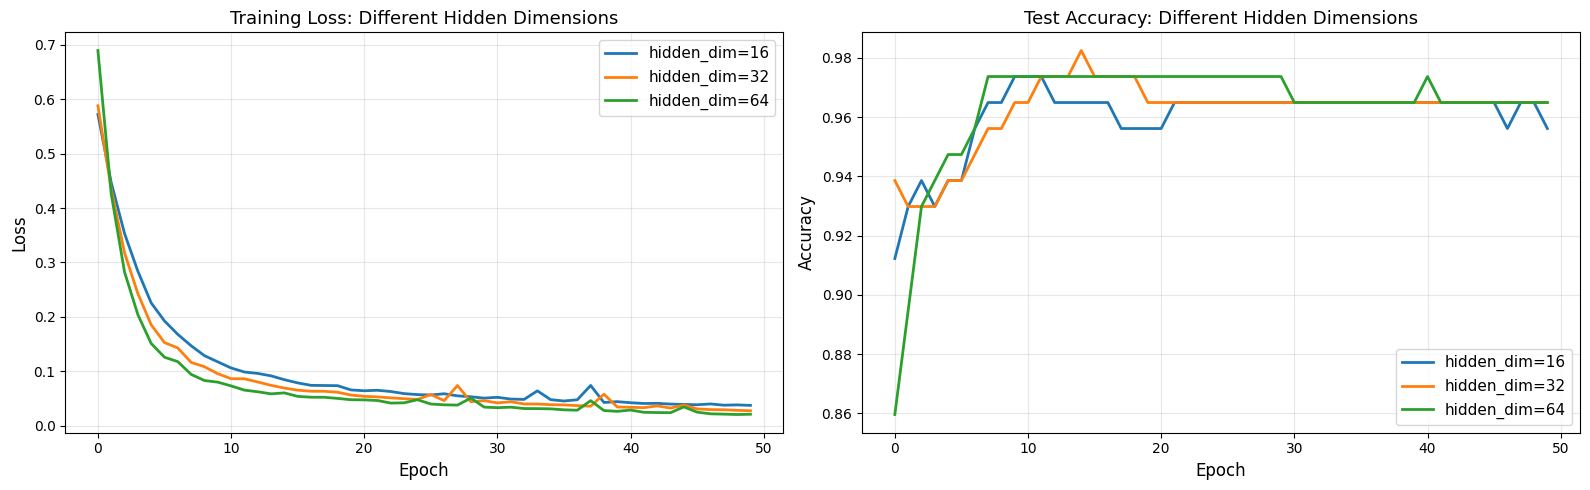

In [21]:

print("Q1: Change hidden_dim to 16, 32, and 64, and find which configuration achieves the best performance.")

hidden_dims = [16, 32, 64]
hidden_dim_results = {}

for hidden_dim in hidden_dims:
    print(f"\n--- Training MLP with hidden_dim = {hidden_dim} ---")
    
    # 모델 생성
    model = MLP(
        input_dim=X_train.shape[1],
        hidden_dim=hidden_dim,
        output_dim=2
    )
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # DataLoader 생성
    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    
    # 학습
    loss_hist, acc_hist = [], []
    
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        
        # 테스트 정확도 계산
        model.eval()
        with torch.no_grad():
            logits_test = model(X_test_t)
            preds = logits_test.argmax(dim=1)
            acc = (preds == y_test_t).float().mean().item()
        
        loss_hist.append(avg_loss)
        acc_hist.append(acc)
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} - loss: {avg_loss:.4f} - acc: {acc:.4f}")
    
    hidden_dim_results[hidden_dim] = {
        'loss_hist': loss_hist,
        'acc_hist': acc_hist,
        'final_acc': acc_hist[-1],
        'best_acc': max(acc_hist)
    }
    
    print(f"Final Accuracy: {acc_hist[-1]:.4f}")
    print(f"Best Accuracy: {max(acc_hist):.4f}")

# 최종 성능 비교

print("Hidden Dimension Comparison Summary")

print(f"{'Hidden Dim':<15} {'Final Acc':<15} {'Best Acc':<15}")
print("-" * 45)
for hidden_dim in hidden_dims:
    print(f"{hidden_dim:<15} {hidden_dim_results[hidden_dim]['final_acc']:.4f}{'':10} {hidden_dim_results[hidden_dim]['best_acc']:.4f}")

best_hidden_dim = max(hidden_dims, key=lambda h: hidden_dim_results[h]['best_acc'])
print(f"\n[Best Configuration] hidden_dim = {best_hidden_dim} with accuracy = {hidden_dim_results[best_hidden_dim]['best_acc']:.4f}")

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss 비교
for hidden_dim in hidden_dims:
    ax1.plot(hidden_dim_results[hidden_dim]['loss_hist'], 
             label=f'hidden_dim={hidden_dim}', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss: Different Hidden Dimensions', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy 비교
for hidden_dim in hidden_dims:
    ax2.plot(hidden_dim_results[hidden_dim]['acc_hist'], 
             label=f'hidden_dim={hidden_dim}', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Test Accuracy: Different Hidden Dimensions', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Q2: Change the learning rate to 1e-4, 1e-3, and 1e-1, and compare training stability.

--- Training MLP with learning_rate = 0.001 ---
Epoch 10/50 - loss: 0.1031 - acc: 0.9561
Epoch 20/50 - loss: 0.0595 - acc: 0.9649
Epoch 30/50 - loss: 0.0434 - acc: 0.9649
Epoch 40/50 - loss: 0.0356 - acc: 0.9561
Epoch 50/50 - loss: 0.0304 - acc: 0.9561
Final Accuracy: 0.9561

--- Training MLP with learning_rate = 0.01 ---
Epoch 10/50 - loss: 0.0184 - acc: 0.9561
Epoch 20/50 - loss: 0.0060 - acc: 0.9561
Epoch 40/50 - loss: 0.0356 - acc: 0.9561
Epoch 50/50 - loss: 0.0304 - acc: 0.9561
Final Accuracy: 0.9561

--- Training MLP with learning_rate = 0.01 ---
Epoch 10/50 - loss: 0.0184 - acc: 0.9561
Epoch 20/50 - loss: 0.0060 - acc: 0.9561
Epoch 30/50 - loss: 0.0023 - acc: 0.9561
Epoch 40/50 - loss: 0.0015 - acc: 0.9561
Epoch 50/50 - loss: 0.0006 - acc: 0.9561
Final Accuracy: 0.9561

--- Training MLP with learning_rate = 0.1 ---
Epoch 10/50 - loss: 0.0091 - acc: 0.9561
Epoch 30/50 - loss: 0.0023 - acc: 0.95

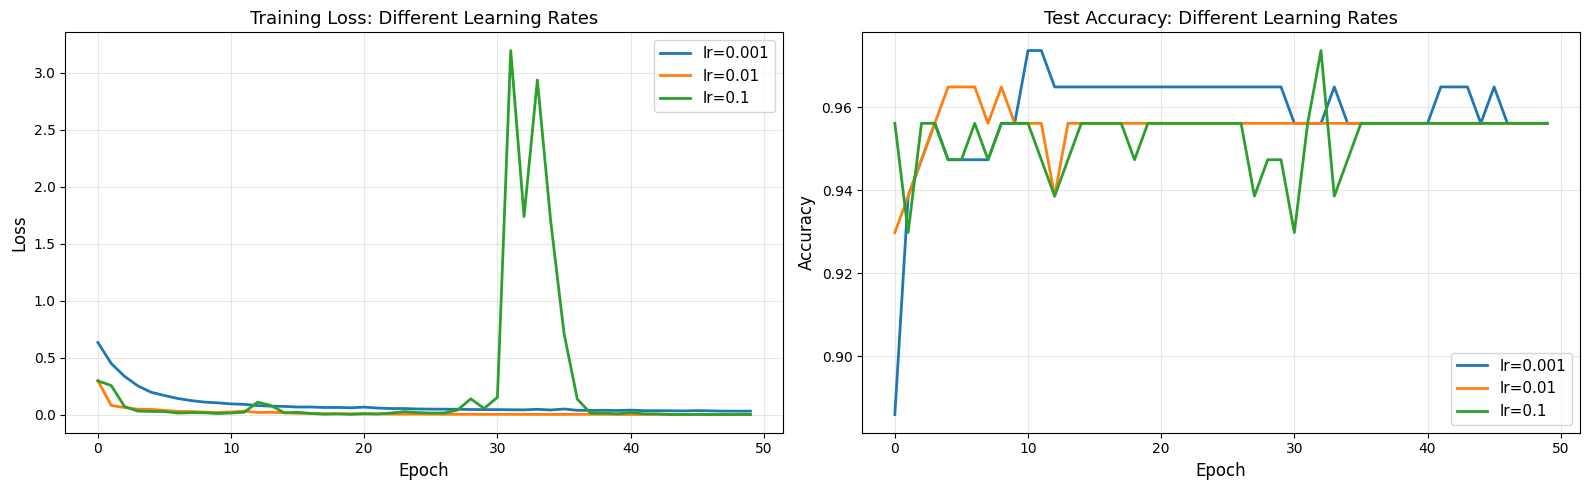

In [22]:
print("Q2: Change the learning rate to 1e-4, 1e-3, and 1e-1, and compare training stability.")

learning_rates = [0.001, 0.01, 0.1]
lr_results = {}

for lr in learning_rates:
    print(f"\n--- Training MLP with learning_rate = {lr} ---")
    
    # 모델 생성
    model = MLP(
        input_dim=X_train.shape[1],
        hidden_dim=32,
        output_dim=2
    )
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # DataLoader 생성
    train_ds = TensorDataset(X_train_t, y_train_t)
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
    
    # 학습
    loss_hist, acc_hist = [], []
    
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(train_loader)
        
        # 테스트 정확도 계산
        model.eval()
        with torch.no_grad():
            logits_test = model(X_test_t)
            preds = logits_test.argmax(dim=1)
            acc = (preds == y_test_t).float().mean().item()
        
        loss_hist.append(avg_loss)
        acc_hist.append(acc)
        
        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} - loss: {avg_loss:.4f} - acc: {acc:.4f}")
    
    lr_results[lr] = {
        'loss_hist': loss_hist,
        'acc_hist': acc_hist,
        'final_acc': acc_hist[-1]
    }
    
    print(f"Final Accuracy: {acc_hist[-1]:.4f}")

# 학습률 비교 요약
print("\nLearning Rate Comparison Summary")
print(f"{'Learning Rate':<15} {'Final Acc':<15}")
print("-" * 30)
for lr in learning_rates:
    print(f"{lr:<15} {lr_results[lr]['final_acc']:.4f}")

# 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Loss 비교 (안정성 확인용)
for lr in learning_rates:
    ax1.plot(lr_results[lr]['loss_hist'], 
             label=f'lr={lr}', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss: Different Learning Rates', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy 비교
for lr in learning_rates:
    ax2.plot(lr_results[lr]['acc_hist'], 
             label=f'lr={lr}', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Test Accuracy: Different Learning Rates', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Q3: Discuss which model—among Random Forest, Bagging, AdaBoost, and MLP—is the most suitable for this dataset.

=== Final Model Performance ===
Model                     Accuracy       
----------------------------------------
Random Forest             0.9561
Bagging                   0.9386
AdaBoost                  0.9561
MLP (best config)         0.9825


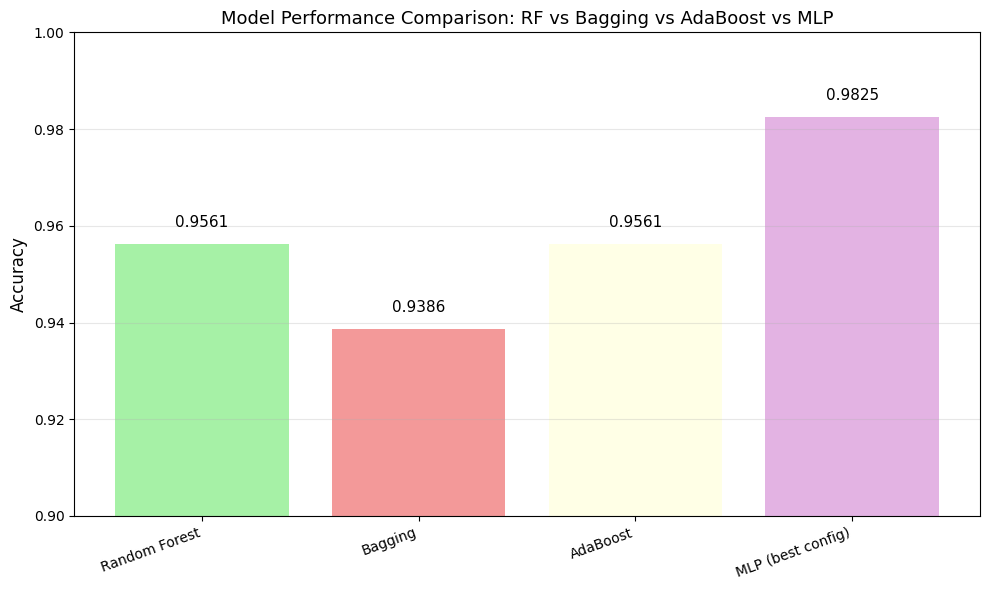

In [23]:
print("Q3: Discuss which model—among Random Forest, Bagging, AdaBoost, and MLP—is the most suitable for this dataset.")

# 과제에서 요구한 4개 모델 성능 수집
all_models = {
    'Random Forest': acc_rf,
    'Bagging': acc_bag,
    'AdaBoost': acc_ada,
    'MLP (best config)': hidden_dim_results[best_hidden_dim]['best_acc']
}

print("\n=== Final Model Performance ===")
print(f"{'Model':<25} {'Accuracy':<15}")
print("-" * 40)
for model_name, acc in all_models.items():
    print(f"{model_name:<25} {acc:.4f}")

# 시각화
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

model_names = list(all_models.keys())
accuracies = list(all_models.values())
colors = ['lightgreen', 'lightcoral', 'lightyellow', 'plum']

bars = ax.bar(model_names, accuracies, color=colors, alpha=0.8)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Model Performance Comparison: RF vs Bagging vs AdaBoost vs MLP', fontsize=13)
ax.set_ylim([0.90, 1.0])
ax.grid(True, alpha=0.3, axis='y')

# 각 막대 위에 정확도 값 표시
for i, (name, acc) in enumerate(zip(model_names, accuracies)):
    ax.text(i, acc + 0.003, f'{acc:.4f}', ha='center', va='bottom', fontsize=11)

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, rotation=20, ha='right')

plt.tight_layout()
plt.show()
